# 1. 특이값 분해(Singular Value Decomposition, SVD)


## 1.1 SVD 소개
모든 실수 행렬 $A \in \mathbb{R}^{m \times n}$에 대해 특이값 분해(SVD) 적용 시, $A$를 다음과 같이 분해할 수 있다:

$$
A = U \Sigma V^T
$$

여기서:

- $U \in \mathbb{R}^{m \times m}$은 정규직교 행렬이며, 열 벡터 $(u_1, u_2, \ldots, u_m)$는 $A$의 좌측 특이벡터(left singular vectors)이다.
- $V \in \mathbb{R}^{n \times n}$은 정규직교 행렬이며, 열 벡터 $(v_1, v_2, \ldots, v_n)$는 $A$의 우측 특이벡터(right singular vectors)이다.
- $\Sigma \in \mathbb{R}^{m \times n}$은 대각선 원소가 음이 아닌 실수인 대각 직사각형 행렬이다. 이 대각선 원소들 $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$이 $A$의 특이값(singular values)이다.

### SVD의 성질
1. $\Sigma$의 대각 원소(특이값)는 $A^T A$ 또는 $A A^T$의 고유값의 제곱근
2. $U$와 $V$의 열은 각각 $A A^T$와 $A^T A$의 고유벡터
3. 모든 실수 행렬 $A$(정방 행렬이든 직사각형 행렬이든)에 대해 SVD는 항상 존재
4. 특이값은 데이터의 분산을 설명하는 역할

**특이값:**

$A$의 특이값 $\sigma_i$는 $A^T A$의 고유값의 제곱근이다. 즉,

$$
\sigma_i(A) = \sqrt{\lambda_i(A^T A)}.
$$

특이값은 내림차순으로 정렬되며 $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > \cdots = 0$이고, 여기서 $r = \mathrm{rank}(A)$ 이다.

## 1.2 SVD의 속성과 정리

1. **정규직교 기저(orthonormal basis):**
   - $U$의 열 벡터는 $\mathbb{R}^m$의 정규직교 기저를 형성.
   - $V$의 열 벡터는 $\mathbb{R}^n$의 정규직교 기저를 형성.

2. **Rank와의 관계:**
   - 0이 아닌 특이값의 개수는 $A$의 rank $r$과 같다.


4. **노름(Norm):**
   - 스펙트럼 노름(Spectral norm) $\|A\|_2$: 가장 큰 특이값 $\sigma_1$ 과 같다.
   - 프로베니우스 노름(Frobenius norm) $\|A\|_F$: $\sqrt{\sum_{i=1}^m \sum_{j=1}^n a_{ij}^2}$으로, $\sqrt{\sum_i \sigma_i^2}$의 값과 같다. ($a_{ij}$는 행렬 A의 원소)


5. **$A^T A$ 및 $AA^T$와의 관계:**
   - $A^T A$와 $AA^T$는 동일한 0이 아닌 고유값을 공유한다.
   - 우측 특이벡터 $(v_i)$는 $A^T A$의 고유벡터이다.
   - 좌측 특이벡터 $(u_i)$는 $AA^T$의 고유벡터이다.

## 1.3 고유값 분해와의 관계
---
### 복습: 고유값 분해

### 정리
대칭(symmetric)이고 양의 정부호(positive definite)인 행렬 $ C \in \mathbb{R}^{n \times n} $에 대해, 다음과 같은 분해가 성립한다:

$$
C = U \Lambda U^T,
$$

여기서:
- $ U $: 정규 직교 행렬 ($ U^T U = I $), 열 벡터는 $ C $의 고유 벡터이다.
- $ \Lambda $: 대각 행렬 ($ \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_n) $), $ C $의 고유값을 포함한다.

### 주요 속성
1. **고유값 ($ \lambda_i $)**: 대칭 양정 행렬의 모든 고유값은 실수이며 양수이다.
2. **고유벡터 ($ u_i $)**: 고유벡터는 정규 직교 기저를 형성하도록 선택할 수 있다.
3. **분해**: 공분산 행렬은 고유벡터의 가중 조합으로 표현될 수 있다.
---

**SVD는:**
- 임의의 $m \times n$ 행렬에 적용된다.
- 항상 음이 아닌 특이값을 생성한다.
- 고유값 분해(EVD)보다 더 일반적이다.

$A$가 대칭이고 양의 준정부호일 때, SVD는 EVD와 일치하며, 특이값은 고유값과 동일하다.

In [1]:
import numpy as np
# 대칭인 양정행렬 (예: 공분산)
S = np.array([[3, 2], [2, 2]])
# SVD 수행
U, Sigma, VT = np.linalg.svd(S)
# EVD 수행
eig_vals, eig_vecs = np.linalg.eigh(S)
# 결과 비교
print("SVD의 특이값:", Sigma)
print("EVD의 고유값:", eig_vals)

SVD의 특이값: [4.56155281 0.43844719]
EVD의 고유값: [0.43844719 4.56155281]


## 1.4 SVD의 응용

### 저랭크 근사

SVD는 행렬 $A$를 분해하여 원래의 전체 랭크 대신, 일부 랭크 $k$를 사용하여 근사 $A_k$를 제공한다:

   $$
   A_k = U_{:,1:k} \Sigma_{1:k,1:k} V_{:,1:k}^T,
   $$
   이는 처음 $k$개의 중요한 성분만 사용하여 원래 행렬 A를 근사한 것이다.


### 주성분 분석(PCA)

PCA는 데이터 행렬의 SVD를 사용하여 계산할 수 있다.
   
우측 특이벡터는 주성분 방향에 해당하며, 특이값은 각 주성분이 설명하는 분산 크기가 된다.

### 유사역행렬(Pseudo Inverse)

SVD를 통해 유사역행렬 $A^+$를 쉽게 계산할 수 있다:

   $$
   A^+ = V \Sigma^+ U^T,
   $$

   여기서 $\Sigma^+$는 0이 아닌 특이값의 역수를 취하여 얻는다.

### 노이즈 제거 및 신호 처리

작은 특이값은 종종 노이즈 방향에 해당하므로 이를 잘라내면 데이터의 노이즈를 제거하고 더 깔끔한 근사를 얻을 수 있다.


## 예제1: 행렬을 SVD로 분해 및 재건하기

In [2]:
# SVD example 1
import numpy as np
A = np.array([[1,2,3],
              [4,5,6],
              [7,8,9],
              [10,11,12]])
U, S, VT = np.linalg.svd(A)
print("U (왼쪽 특이벡터):\n", U)
print("Sigma (특이값):\n", S)
print("V^T (오른쪽 특이벡터):\n", VT)

U (왼쪽 특이벡터):
 [[-0.14087668 -0.82471435  0.54704904 -0.02715407]
 [-0.34394629 -0.42626394 -0.70915928  0.4439517 ]
 [-0.54701591 -0.02781353 -0.22282857 -0.80644121]
 [-0.75008553  0.37063688  0.38493881  0.38964357]]
Sigma (특이값):
 [2.54624074e+01 1.29066168e+00 1.80972823e-15]
V^T (오른쪽 특이벡터):
 [[-0.50453315 -0.5745157  -0.64449826]
 [ 0.76077568  0.05714052 -0.64649464]
 [-0.40824829  0.81649658 -0.40824829]]


In [3]:
# 행렬 A는 두 특이값만으로 완벽히 복원 가능
k = 2
S_k = np.zeros_like(A, dtype=float)
np.fill_diagonal(S_k[:k, :k], S[:k])
print(S_k)

[[25.46240744  0.          0.        ]
 [ 0.          1.29066168  0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]]


In [4]:
A_k = U[:, :k] @ S_k[:k, :k] @ VT[:k, :]
print(A_k)

[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]]


In [5]:
# 오차 측정: Frobenius norm
np.linalg.norm(A - A_k)

np.float64(1.4472130815335338e-14)

## 예제2: 그림 파일을 SVD로 분해 및 재건하기

In [6]:
# SVD example 2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
# Load an image using Matplotlib
image = imread("flower.jpg")
image_gray = np.mean(image, axis=2)

In [7]:
plt.rcParams.update({'font.size': 20})  # 전역 폰트 크기를 20로 설정

In [8]:
# Perform SVD on the image
U, Sigma, VT = np.linalg.svd(image_gray, full_matrices=False)
# Reconstruct the image using the top k singular values.
def reconstruct_image(U, Sigma, VT, k):
    Sigma_k = np.diag(Sigma[:k])
    U_k = U[:, :k]
    VT_k = VT[:k, :]
    return U_k @ Sigma_k @ VT_k

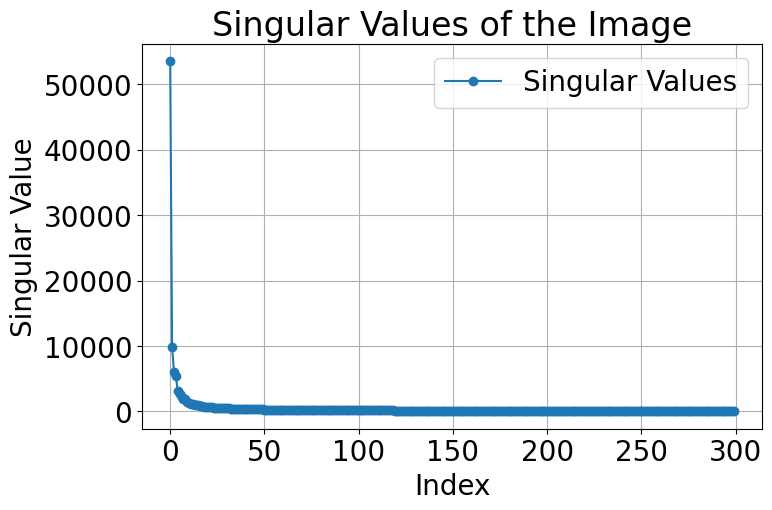

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(Sigma, marker='o', linestyle='-', label="Singular Values")
plt.title("Singular Values of the Image")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
k_values = [5, 20, 50, 100]
[Sigma[i - 1] for i in k_values]

[np.float64(3130.1017184607063),
 np.float64(663.796388013893),
 np.float64(284.1193370091631),
 np.float64(149.5137812591052)]

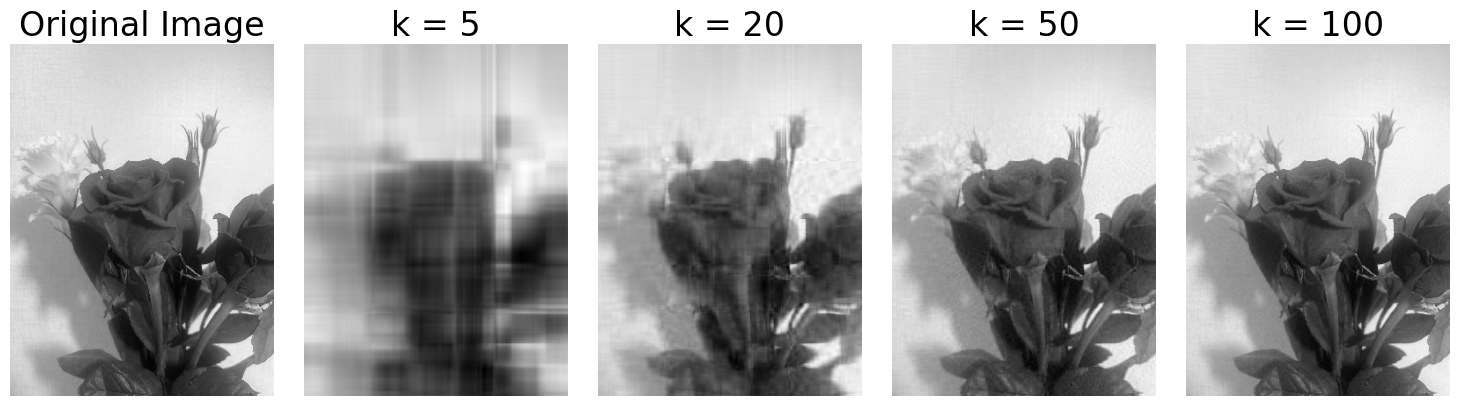

In [11]:
# Reconstruct the image using different numbers of singular values
k_values = [5, 20, 50, 100]
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(15, 5))
# Original image
axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")
# Reconstructed images
for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(U, Sigma, VT, k)
    axes[i + 1].imshow(reconstructed, cmap="gray")
    axes[i + 1].set_title(f"k = {k}")
    axes[i + 1].axis("off")
plt.tight_layout()
plt.show()

## SVD 요약

- **SVD**: 모든 $A \in \mathbb{R}^{m \times n}$에 대해 $A = U \Sigma V^T$로 분해하는 범용적 방법.
- **특이값**: $A$가 벡터를 특정 방향에서 얼마나 늘리는지를 측정하는 음이 아닌 값.
- **좌측 및 우측 특이벡터**: $A$가 벡터의 방향을 어떻게 바꾸는지를 나타냄.
- **응용**: 저랭크 근사, PCA, 유사역행렬, 노이즈 제거 등.

# 2. 주성분 분석 (Principal Component Analysis, PCA)

### PCA란?
- 고차원 데이터에서 변동(분산)을 기준으로 새로운 축(주성분)을 찾는 기법. 
- 고차원 데이터를 저차원으로 투영(Projection)하면서도 데이터의 분산을 최대한 유지.
- 구체적으로, 데이터의 공분산 구조를 분석하여 주성분을 분산 크기 순으로 정렬.
- PCA를 통해 다차원 데이터를 저차원의 주성분으로 요약 가능.
- 응용 분야: 노이즈 제거, 압축, 시각화(2D 또는 3D), Feature Extraction 등.

### PCA 진행 아이디어
- 고차원 데이터의 분포를 가장 잘 설명하는 직교 성분(Principal Components)을 찾는다.
- 첫 번째 주성분(PC1)은 데이터 분산이 가장 큰 방향을 나타내고,  
  두 번째 주성분(PC2)은 첫 번째 주성분에 직교하면서 그 다음으로 큰 분산 방향을 나타내는 식으로 진행된다.
- 상위 $M$개 주성분을 선택하면, $M$차원으로 데이터 차원을 축소하면서도 데이터의 중요한 변동 정보를 최대한 유지할 수 있다.

### PCA 투영(Projection):

임의의 데이터 벡터 $x \in \mathbb{R}^D$는 고유벡터의 선형 결합으로 표현될 수 있다:

$$
x = \langle x, u_1 \rangle u_1 + \langle x, u_2 \rangle u_2 + \cdots + \langle x, u_D \rangle u_D.
$$

PCA는 가장 큰 고유값에 대응하는 상위 $M$개의 주성분에 데이터를 투영하여 $x$의 저차원 표현을 찾는 것을 목표로 한다.

# PCA를 진행하는 두 가지 방법
1. 중심화된 데이터 행렬의 SVD
2. 중심화된 데이터의 공분산 행렬의 SVD(=EVD)

## 2.1 중심화된 데이터 행렬의 SVD를 사용한 PCA

### 데이터 행렬 $X$
주성분 분석을 수행하기 위해 데이터 행렬 $X \in \mathbb{R}^{N \times D}$ (샘플 $N$, 변수 $D$)를 중심화:
   $$
   X_{\text{centered}} = X - \text{mean}(X)
   $$

### SVD 수행
중심화된 데이터 행렬 $X_{\text{centered}}$에 대해 특이값 분해(SVD)를 수행:
$$
X_{\text{centered}} = U \Sigma V^T
$$
- $U \in \mathbb{R}^{N \times N}$: $X_{\text{centered}} X_{\text{centered}}^T$의 고유벡터.
- $\Sigma \in \mathbb{R}^{N \times D}$: 대각 행렬로, 특이값을 포함.
- $V \in \mathbb{R}^{D \times D}$: $X_{\text{centered}}^T X_{\text{centered}}$의 고유벡터.

### 결과 해석
1. **주성분 방향**:
   - 행렬 $V^T$의 행 벡터가 주성분 방향을 나타냄.
2. **주성분 점수**:
   - 행렬 $U \Sigma$는 데이터가 주성분 방향으로 투영된 값을 나타냄.
3. **분산**:
   - 특이값, 즉 $\Sigma$의 원소들을 제곱하여 자유도($N-1$)로 나눈 값은 각 주성분의 분산 크기(고유값)를 나타냄:
     $$
     \frac{\sigma_i^2}{N-1} = \text{V[PC}_i \text{]} = \lambda_i.
     $$
     여기서, $\sigma_i$는 특이값 행렬$\Sigma$의 $i$번째 대각원소, 즉, $i$번째 특이값이고, $\lambda_i$는 $i$번째 고유값(아래 2.2절 참고).

## 2.2 중심화된 데이터의 공분산 행렬의 EVD를 사용한 PCA

### 공분산 행렬의 정의
중심화된 데이터 $X_{\text{centered}} \in \mathbb{R}^{N \times D}$의 공분산 행렬 $S \in \mathbb{R}^{D \times D}$는 다음과 같이 정의된다:
$$
S = \frac{1}{N-1} X_{\text{centered}}^T X_{\text{centered}}
$$


### EVD 수행
공분산 행렬 $S$에 대해 고유값 분해를 수행한다:
$$
S = Q \Lambda Q^T
$$
- $Q \in \mathbb{R}^{D \times D}$: 공분산 행렬의 고유벡터(주성분 방향).
- $\Lambda \in \mathbb{R}^{D \times D}$: 공분산 행렬의 고유값(각 주성분의 분산 크기).

---
**참고: 공분산 행렬을 특이값 분해(SVD)할 경우, 그 결과는 고유값 분해(EVD)와 동일하다.**

공분산 행렬 $S \in \mathbb{R}^{D \times D}$은 대칭 행렬이므로, 정규직교 고유기저(orthonormal eigenbasis)를 통해 대각화할 수 있다:

$$
S u_i = \lambda_i u_i, \quad i = 1, \ldots, D,
$$

여기서 $\{u_1, u_2, \ldots, u_D\}$는 크기가 1이고 직교하는 고유벡터 집합이고, $\{\lambda_1, \lambda_2, \ldots, \lambda_D\}$는 해당하는 고유값 집합이다. 고유값은 $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_D \geq 0$ 순서로 정렬된다.

---

### 결과 해석
1. **주성분 방향**:
   - 행렬 $Q$의 열 벡터가 주성분 방향을 나타냄.
2. **분산**:
   - 고유값 $\lambda_i$는 $\Lambda$의 $i$번째 대각원소로, 각 주성분의 분산 크기를 나타냄:
     $$
     \text{V[PC}_i \text{]} = \lambda_i
     $$

## 예제1: 2차원 데이터를 1차원으로 축소하기
PCA가 데이터의 변동성을 최대한 유지하면서 차원을 축소하는 원리를 시각적으로 확인해보자.

2차원 평면 상에 분포된 점들을 PCA를 이용해 1차원으로 축소
- 원본 데이터: 2차원 
- PCA 적용 후: 가장 분산이 큰 방향(주성분)을 찾아 그 축으로 데이터를 투영 → 1차원 데이터



In [12]:
# PCA example 1: 이변량 정규분포
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

N = 100
mean = np.array([0, 0])
cov = np.array([[3, 2], [2, 2]])
mvn_rv = multivariate_normal(mean=mean, cov=cov)
X = mvn_rv.rvs(size=N, random_state=1)

# PCA를 수행하기 위한 SVD
X_mean = X.mean(axis=0)
X_centered = X - X_mean
U, S, Vt = np.linalg.svd(X_centered) 
# 첫 번째 주성분
PC1 = Vt[0]  
# 두 번째 주성분
PC2 = Vt[1]
# 1차원으로 투영: X_centered를 PC1 방향으로 내적
X_projected_1D = X_centered @ PC1

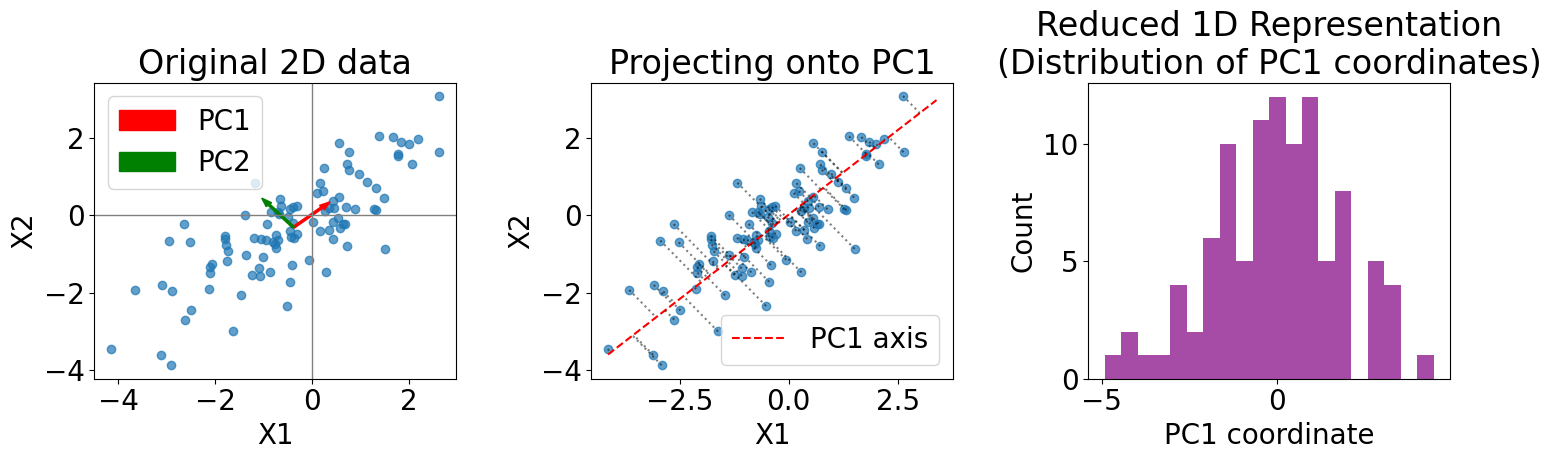

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# (1) 원본 데이터 산점도
ax[0].scatter(X[:,0], X[:,1], alpha=0.7)
ax[0].set_title("Original 2D data")
ax[0].set_xlabel("X1")
ax[0].set_ylabel("X2")
ax[0].axhline(0, color='grey', linewidth=1)
ax[0].axvline(0, color='grey', linewidth=1)
# 주성분 방향 표시
origin = X_mean
ax[0].arrow(origin[0], origin[1], PC1[0], PC1[1], 
            width=0.05, color='red', length_includes_head=True, label='PC1')
ax[0].arrow(origin[0], origin[1], PC2[0], PC2[1], 
            width=0.05, color='green', length_includes_head=True, label='PC2')
ax[0].legend()

# (2) 주성분 1축(PC1)에 대한 투영
line_range = np.linspace(-5,5,2)
pc1_line = origin + np.outer(line_range, PC1)
ax[1].scatter(X[:,0], X[:,1], alpha=0.7)
ax[1].plot(pc1_line[:,0], pc1_line[:,1], 'r--', label='PC1 axis')
# 각 점을 PC1 축으로 수직 투영하는 선 표시
for i in range(N):
    proj_point = origin + (X_projected_1D[i])*PC1
    ax[1].plot([X[i,0], proj_point[0]], [X[i,1], proj_point[1]], 'k:', alpha=0.5)
ax[1].set_title("Projecting onto PC1")
ax[1].set_xlabel("X1")
ax[1].set_ylabel("X2")
ax[1].legend()

# (3) 투영 결과 (1차원 표현)
# X_projected_1D는 N x 1 차원 데이터: PC1 방향의 좌표
ax[2].hist(X_projected_1D, bins=20, alpha=0.7, color='purple')
ax[2].set_title("Reduced 1D Representation\n(Distribution of PC1 coordinates)")
ax[2].set_xlabel("PC1 coordinate")
ax[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 예제2: Iris 데이터의 주성분 추출하기
Iris 데이터의 4차원 변수를 변동성을 최대한 유지하면서 2차원으로 축소해보자.

- 원본 데이터: 4차원 
- PCA 적용 후: 가장 분산이 큰 방향들(주성분)을 찾아 그 축으로 데이터를 투영 → 2차원 데이터


In [14]:
# PCA example 2: iris data
import pandas as pd
iris = pd.read_csv("iris.csv")
iris_num = iris.iloc[:, 0:4]
iris_mean = np.mean(iris_num, axis=0)
iris_std = np.std(iris_num, axis=0)
iris_standard = (iris_num - iris_mean) / iris_std
print(iris_standard.head())
print(iris_standard.agg(['mean', 'std', 'min', 'max']))

   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
0     -0.900681     1.019004     -1.340227    -1.315444
1     -1.143017    -0.131979     -1.340227    -1.315444
2     -1.385353     0.328414     -1.397064    -1.315444
3     -1.506521     0.098217     -1.283389    -1.315444
4     -1.021849     1.249201     -1.340227    -1.315444
      Sepal.Length   Sepal.Width  Petal.Length   Petal.Width
mean -4.736952e-16 -7.815970e-16 -4.263256e-16 -4.736952e-16
std   1.003350e+00  1.003350e+00  1.003350e+00  1.003350e+00
min  -1.870024e+00 -2.433947e+00 -1.567576e+00 -1.447076e+00
max   2.492019e+00  3.090775e+00  1.785832e+00  1.712096e+00


In [16]:
covariance_matrix = np.cov(iris_standard, rowvar=False)
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
print(eigen_values)
print(eigen_vectors)

[2.93808505 0.9201649  0.14774182 0.02085386]
[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [17]:
UU, SS, VVT = np.linalg.svd(iris_standard)
e_val, e_vec = np.linalg.eigh(covariance_matrix)
print(SS**2/149)
print(e_val)
covariance_matrix

[2.93808505 0.9201649  0.14774182 0.02085386]
[0.02085386 0.14774182 0.9201649  2.93808505]


array([[ 1.00671141, -0.11835884,  0.87760447,  0.82343066],
       [-0.11835884,  1.00671141, -0.43131554, -0.36858315],
       [ 0.87760447, -0.43131554,  1.00671141,  0.96932762],
       [ 0.82343066, -0.36858315,  0.96932762,  1.00671141]])

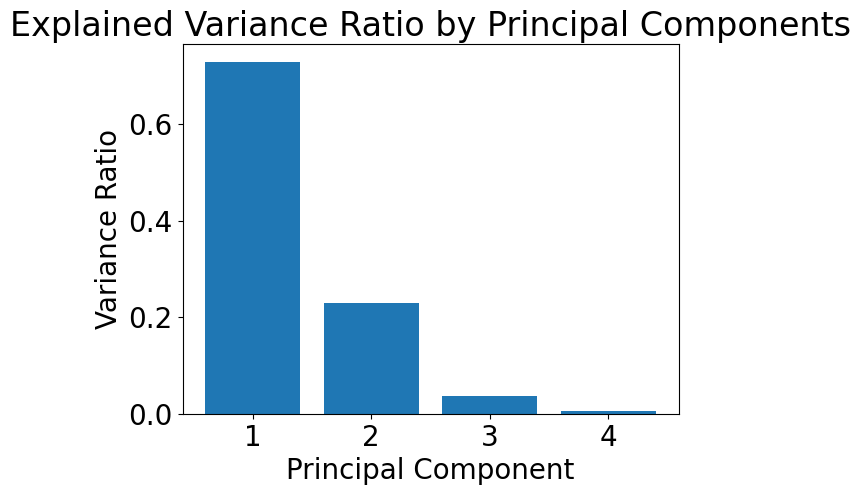

In [43]:
# Explained variance ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.title("Explained Variance Ratio by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.show()

In [44]:
pc_2 = eigen_vectors[:, :2]
transformed_2 = np.dot(iris_standard, pc_2)
print(transformed_2[:7])

[[-2.26470281 -0.4800266 ]
 [-2.08096115  0.67413356]
 [-2.36422905  0.34190802]
 [-2.29938422  0.59739451]
 [-2.38984217 -0.64683538]
 [-2.07563095 -1.48917752]
 [-2.44402884 -0.0476442 ]]


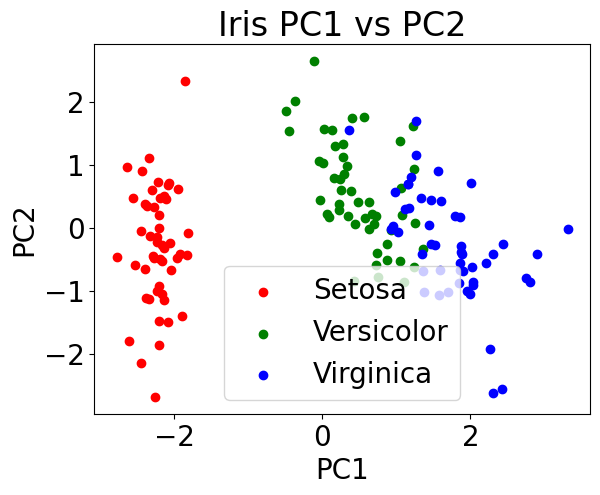

In [45]:
species = iris['Species'].values
setosa_tr2 = transformed_2[species == 'setosa']
versicolor_tr2 = transformed_2[species == 'versicolor']
virginica_tr2 = transformed_2[species == 'virginica']

plt.scatter(setosa_tr2[:,0], setosa_tr2[:,1],
            color='red', label='Setosa')
plt.scatter(versicolor_tr2[:,0], versicolor_tr2[:,1],
            color='green', label='Versicolor')
plt.scatter(virginica_tr2[:,0], virginica_tr2[:,1],
            color='blue', label='Virginica')

plt.title('Iris PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.legend()
plt.show()

## PCA 요약
- PCA는 고차원 데이터에서 최대한 많은 분산을 설명하는 축을 찾아내어, 낮은 차원으로 투영하는 차원 축소 기법이다.
- PCA는 중심화된 데이터 행렬을 SVD하여 진행할 수 있다.
- PCA는 중심화된 데이터의 공분산 행렬을 EVD하여 진행할 수도 있다.
- 응용: 노이즈 제거, 압축, 시각화(2D 또는 3D), Feature Extraction 등.